In [1]:
import os
from PIL import Image

# Path to dataset root (relative to notebooks/ folder)
DATASET_DIR = "../Dataset/Wheat varieties dataset"

# List classes (folders), ignoring hidden system files like .DS_Store
classes = [c for c in os.listdir(DATASET_DIR) if not c.startswith('.')]
print("Classes found:", classes)

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    print(f"{cls}: {len(images)} images")

Classes found: ['Dilkash', 'Akbar', 'urooj']
Dilkash: 125 images
Akbar: 125 images
urooj: 125 images


In [2]:
sizes = set()
modes = set()
corrupted = []

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    for img_name in images:
        img_path = os.path.join(cls_path, img_name)
        try:
            with Image.open(img_path) as img:
                sizes.add(img.size)
                modes.add(img.mode)
        except Exception as e:
            corrupted.append((img_path, str(e)))

print("Unique image sizes found:", sizes)
print("Unique color modes found:", modes)
print("Number of corrupted/unreadable images:", len(corrupted))
if corrupted:
    print("Corrupted files:", corrupted)

Unique image sizes found: set()
Unique color modes found: set()
Number of corrupted/unreadable images: 375
Corrupted files: [('../Dataset/Wheat varieties dataset/Dilkash/D12', "[Errno 21] Is a directory: '../Dataset/Wheat varieties dataset/Dilkash/D12'"), ('../Dataset/Wheat varieties dataset/Dilkash/D15', "[Errno 21] Is a directory: '../Dataset/Wheat varieties dataset/Dilkash/D15'"), ('../Dataset/Wheat varieties dataset/Dilkash/D23', "[Errno 21] Is a directory: '../Dataset/Wheat varieties dataset/Dilkash/D23'"), ('../Dataset/Wheat varieties dataset/Dilkash/D104', "[Errno 21] Is a directory: '../Dataset/Wheat varieties dataset/Dilkash/D104'"), ('../Dataset/Wheat varieties dataset/Dilkash/D103', "[Errno 21] Is a directory: '../Dataset/Wheat varieties dataset/Dilkash/D103'"), ('../Dataset/Wheat varieties dataset/Dilkash/D24', "[Errno 21] Is a directory: '../Dataset/Wheat varieties dataset/Dilkash/D24'"), ('../Dataset/Wheat varieties dataset/Dilkash/D70', "[Errno 21] Is a directory: '../Da

In [3]:
# Investigate what's inside one sample folder
sample_folder = os.path.join(DATASET_DIR, "Akbar", "A1")
print("Contents of A1 folder:")
for item in os.listdir(sample_folder):
    print(" -", item)

Contents of A1 folder:
 - b.jpg
 - c.jpg
 - a.jpg


In [4]:
total_samples = 0
total_images = 0
images_per_sample = set()

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    samples = [s for s in os.listdir(cls_path) if not s.startswith('.')]
    for sample in samples:
        sample_path = os.path.join(cls_path, sample)
        if os.path.isdir(sample_path):
            total_samples += 1
            imgs = [f for f in os.listdir(sample_path) if not f.startswith('.')]
            total_images += len(imgs)
            images_per_sample.add(len(imgs))

print("Total sample folders (seeds):", total_samples)
print("Total actual image files:", total_images)
print("Number of images per sample folder (should ideally be same for all):", images_per_sample)

Total sample folders (seeds): 375
Total actual image files: 1124
Number of images per sample folder (should ideally be same for all): {1, 2, 3, 4}


In [5]:
inconsistent = []

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    samples = [s for s in os.listdir(cls_path) if not s.startswith('.')]
    for sample in samples:
        sample_path = os.path.join(cls_path, sample)
        if os.path.isdir(sample_path):
            imgs = [f for f in os.listdir(sample_path) if not f.startswith('.')]
            if len(imgs) != 3:
                inconsistent.append((cls, sample, len(imgs), imgs))

print(f"Total inconsistent folders: {len(inconsistent)}")
print("-" * 50)
for cls, sample, count, imgs in inconsistent:
    print(f"{cls}/{sample}: {count} images -> {imgs}")

Total inconsistent folders: 6
--------------------------------------------------
Akbar/A34: 4 images -> ['IMG_7558.jpg', 'IMG_7559.jpg', 'IMG_7561.jpg', 'IMG_7560.jpg']
Akbar/A43: 4 images -> ['IMG_7592.jpg', 'IMG_7593.jpg', 'IMG_7591.jpg', 'IMG_7594.jpg']
Akbar/A11: 2 images -> ['IMG_7485.jpg', 'IMG_7486.jpg']
Akbar/A16: 2 images -> ['IMG_7502.jpg', 'IMG_7503.jpg']
Akbar/A37: 4 images -> ['IMG_7594.jpg', 'IMG_7568.jpg', 'IMG_7569.jpg', 'IMG_7570.jpg']
Akbar/A9: 1 images -> ['IMG_7481.jpg']


In [6]:
sizes = set()
modes = set()
corrupted = []
all_image_paths = []  # we'll need this list later too

for cls in classes:
    cls_path = os.path.join(DATASET_DIR, cls)
    samples = [s for s in os.listdir(cls_path) if not s.startswith('.')]
    for sample in samples:
        sample_path = os.path.join(cls_path, sample)
        if not os.path.isdir(sample_path):
            continue
        img_files = [f for f in os.listdir(sample_path) if not f.startswith('.')]
        for img_file in img_files:
            img_path = os.path.join(sample_path, img_file)
            all_image_paths.append((img_path, cls, sample))
            try:
                with Image.open(img_path) as img:
                    sizes.add(img.size)
                    modes.add(img.mode)
            except Exception as e:
                corrupted.append((img_path, str(e)))

print("Total real image files found:", len(all_image_paths))
print("Unique image sizes found:", sizes)
print("Unique color modes found:", modes)
print("Number of corrupted/unreadable images:", len(corrupted))
if corrupted:
    print("Corrupted files:", corrupted)

Total real image files found: 1124
Unique image sizes found: {(256, 256)}
Unique color modes found: {'RGB'}
Number of corrupted/unreadable images: 0


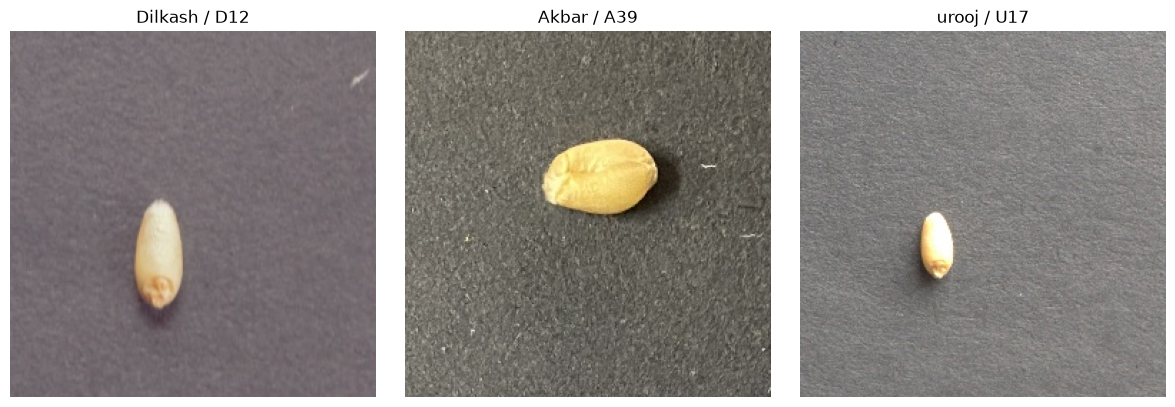

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sample_choices = [
    all_image_paths[0],
    all_image_paths[len(all_image_paths)//2],
    all_image_paths[-1]
]

for ax, (path, cls, sample) in zip(axes, sample_choices):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"{cls} / {sample}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# Build a clean dataframe: image_path, class_name, class_id, sample_id
class_to_id = {cls: idx for idx, cls in enumerate(sorted(classes))}
print("Class to ID mapping:", class_to_id)

records = []
for img_path, cls, sample in all_image_paths:
    records.append({
        "image_path": img_path,
        "class_name": cls,
        "class_id": class_to_id[cls],
        "sample_id": sample  # e.g., 'A1', 'D12' — used later to prevent data leakage
    })

df = pd.DataFrame(records)
print("\nTotal records:", len(df))
print("\nClass distribution (image-level):")
print(df['class_name'].value_counts())
print("\nSample of the dataframe:")
df.head()

Class to ID mapping: {'Akbar': 0, 'Dilkash': 1, 'urooj': 2}

Total records: 1124

Class distribution (image-level):
class_name
Dilkash    375
urooj      375
Akbar      374
Name: count, dtype: int64

Sample of the dataframe:


,image_path,class_name,class_id,sample_id
0,../Dataset/Wheat varieties dataset/Dilkash/D12...,Dilkash,1,D12
1,../Dataset/Wheat varieties dataset/Dilkash/D12...,Dilkash,1,D12
2,../Dataset/Wheat varieties dataset/Dilkash/D12...,Dilkash,1,D12
3,../Dataset/Wheat varieties dataset/Dilkash/D15...,Dilkash,1,D15
4,../Dataset/Wheat varieties dataset/Dilkash/D15...,Dilkash,1,D15


In [9]:
output_path = "../Dataset/dataset_index.csv"
df.to_csv(output_path, index=False)
print(f"Saved dataset index to: {output_path}")
print(f"Total rows saved: {len(df)}")

Saved dataset index to: ../Dataset/dataset_index.csv
Total rows saved: 1124


In [10]:
import tensorflow as tf
from tensorflow.keras import layers

# Define augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),        # up to ~15% of 360°, i.e. ~54 degrees max
    layers.RandomBrightness(0.15),      # slight brightness variation
    layers.RandomContrast(0.15),        # slight contrast variation
])

print("Augmentation pipeline created successfully.")

Augmentation pipeline created successfully.


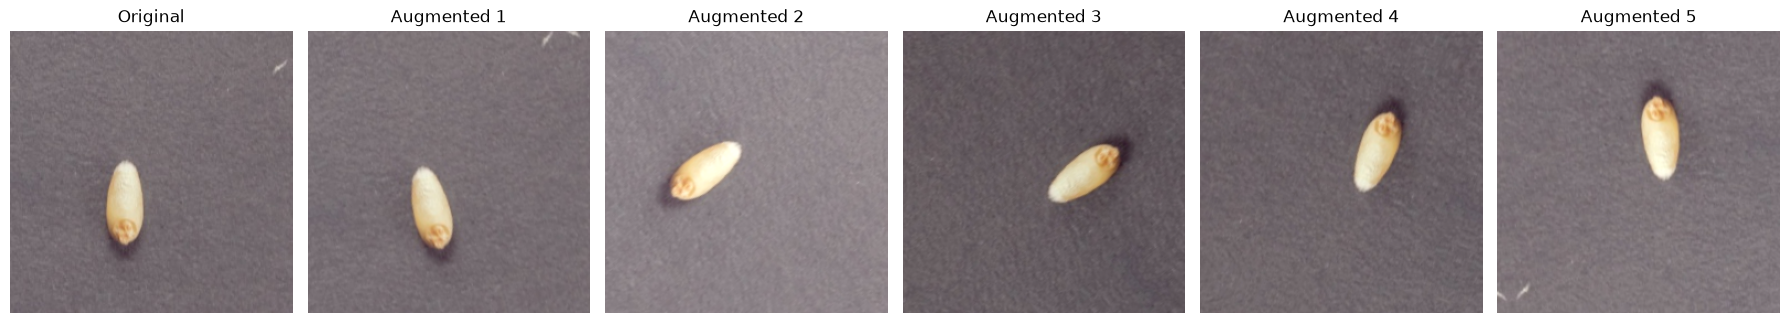

In [11]:
import numpy as np

# Pick one real sample image
sample_path = all_image_paths[0][0]
img = Image.open(sample_path)
img_array = np.array(img)
img_tensor = tf.expand_dims(img_array, 0)  # add batch dimension

# Generate 5 augmented versions of the same image
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(1, 6):
    augmented = data_augmentation(img_tensor, training=True)
    augmented_img = tf.cast(augmented[0], tf.uint8).numpy()
    axes[i].imshow(augmented_img)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Get unique sample-level records (one row per seed, not per image)
unique_samples = df[['sample_id', 'class_name', 'class_id']].drop_duplicates().reset_index(drop=True)
print("Total unique seed samples:", len(unique_samples))
print(unique_samples['class_name'].value_counts())

Total unique seed samples: 375
class_name
Dilkash    125
Akbar      125
urooj      125
Name: count, dtype: int64


In [13]:
# Step 1: Split seeds into train (70%) and temp (30%)
train_samples, temp_samples = train_test_split(
    unique_samples,
    test_size=0.30,
    stratify=unique_samples['class_name'],
    random_state=42
)

# Step 2: Split temp into validation (15%) and test (15%) — i.e., 50/50 of the 30%
val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.50,
    stratify=temp_samples['class_name'],
    random_state=42
)

print("Train seeds:", len(train_samples))
print("Validation seeds:", len(val_samples))
print("Test seeds:", len(test_samples))

print("\nTrain class distribution:")
print(train_samples['class_name'].value_counts())
print("\nValidation class distribution:")
print(val_samples['class_name'].value_counts())
print("\nTest class distribution:")
print(test_samples['class_name'].value_counts())

Train seeds: 262
Validation seeds: 56
Test seeds: 57

Train class distribution:
class_name
Akbar      88
urooj      87
Dilkash    87
Name: count, dtype: int64

Validation class distribution:
class_name
urooj      19
Dilkash    19
Akbar      18
Name: count, dtype: int64

Test class distribution:
class_name
Dilkash    19
Akbar      19
urooj      19
Name: count, dtype: int64


In [14]:
# Create a mapping from sample_id -> split
split_map = {}
for sid in train_samples['sample_id']:
    split_map[sid] = 'train'
for sid in val_samples['sample_id']:
    split_map[sid] = 'val'
for sid in test_samples['sample_id']:
    split_map[sid] = 'test'

# Apply mapping to full image-level dataframe
df['split'] = df['sample_id'].map(split_map)

# Verify: every row should have a split assigned (no NaN)
print("Missing split assignments:", df['split'].isna().sum())

print("\nImage-level split counts:")
print(df['split'].value_counts())

print("\nImage-level split x class breakdown:")
print(df.groupby(['split', 'class_name']).size())

Missing split assignments: 0

Image-level split counts:
split
train    784
test     172
val      168
Name: count, dtype: int64

Image-level split x class breakdown:
split  class_name
test   Akbar          58
       Dilkash        57
       urooj          57
train  Akbar         262
       Dilkash       261
       urooj         261
val    Akbar          54
       Dilkash        57
       urooj          57
dtype: int64


In [15]:
final_output_path = "../Dataset/dataset_index_with_splits.csv"
df.to_csv(final_output_path, index=False)
print(f"Saved final dataset index to: {final_output_path}")
print(f"Total rows: {len(df)}")

# Quick final sanity check: no seed appears in more than one split
leakage_check = df.groupby('sample_id')['split'].nunique()
leaking_samples = leakage_check[leakage_check > 1]
print(f"\nSeeds appearing in multiple splits (should be 0): {len(leaking_samples)}")


Saved final dataset index to: ../Dataset/dataset_index_with_splits.csv
Total rows: 1124

Seeds appearing in multiple splits (should be 0): 0
